In [1]:
import pandas as pd
import os
original_file = 'purchases.csv'
sample_file = 'purchases_sample_25mb.csv'
sampling_fraction = 0.05
random_seed = 42
chunk_size = 100000
print("Starting simple random sampling...")
sampled_chunks = []
for chunk in pd.read_csv(original_file, chunksize=chunk_size, low_memory=False):
    sampled_chunk = chunk.sample(frac=sampling_fraction, random_state=random_seed)
    sampled_chunks.append(sampled_chunk)
df_sample = pd.concat(sampled_chunks, ignore_index=True)
df_sample.to_csv(sample_file, index=False)
original_size_mb = os.path.getsize(original_file) / (1024 * 1024)
sample_size_mb = os.path.getsize(sample_file) / (1024 * 1024)
print("Sampling completed successfully!")
print("Original file size: " + str(round(original_size_mb, 1)) + " MB")
print("Sample file size: " + str(round(sample_size_mb, 1)) + " MB")
print("Number of rows in sample: " + str(len(df_sample)))
print("Sample file saved as: " + sample_file)

Starting simple random sampling...
Sampling completed successfully!
Original file size: 344.8 MB
Sample file size: 17.4 MB
Number of rows in sample: 118624
Sample file saved as: purchases_sample_25mb.csv


In [2]:
import pandas as pd
df = pd.read_csv('purchases_sample_25mb.csv')
print("Data loaded successfully!")
print("Shape of the dataset: " + str(df.shape))
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())
print("\nNumber of unique vendors/suppliers:")
print(df['VendorID'].nunique() if 'VendorID' in df.columns else "VendorID column not found")
print("\nMissing values in each column:")
print(df.isnull().sum())
print("\nData types of columns:")
print(df.dtypes)

Data loaded successfully!
Shape of the dataset: (118624, 16)

Column names:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

First 5 rows:
           InventoryId  Store  Brand                  Description   Size  \
0    27_MOUNTMEND_5661     27   5661  Dr McGillicuddy's Root Beer  750mL   
1    34_PITMERDEN_4899     34   4899  Clement Mahina Coco Liqueur  750mL   
2   74_PAENTMARWY_3879     74   3879   Smirnoff 80 Proof Traveler  750mL   
3      10_HORNSEY_3687     10   3687  Fleischmanns Royal Traveler  750mL   
4  59_CLAETHORPES_8905     59   8905  Livingston Cellars Red Rose     3L   

   VendorNumber                   VendorName  PONumber      PODate  \
0          8004  SAZERAC CO INC                   8366  2024-01-06   
1          9165  ULTRA BEVERAGE COMPANY LLP       8371  2024-01-06   
2          3960  DIAGEO NORTH AM

In [3]:
import pandas as pd
df = pd.read_csv('purchases_sample_25mb.csv')
df['PODate'] = pd.to_datetime(df['PODate'])
df['ReceivingDate'] = pd.to_datetime(df['ReceivingDate'])
df['LeadTimeDays'] = (df['ReceivingDate'] - df['PODate']).dt.days
df['OnTime'] = (df['LeadTimeDays'] <= 14).astype(int)
supplier_summary = df.groupby('VendorName').agg(
    Total_Spend=('Dollars', 'sum'),
    Total_Orders=('PONumber', 'nunique'),
    Avg_Purchase_Price=('PurchasePrice', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_LeadTime=('LeadTimeDays', 'mean'),
    OnTime_Rate=('OnTime', 'mean'),
    Total_Quantity=('Quantity', 'sum')
).round(2)
supplier_summary = supplier_summary.reset_index()
supplier_summary['OnTime_Rate'] = (supplier_summary['OnTime_Rate'] * 100).round(1)
supplier_summary = supplier_summary.sort_values('Total_Spend', ascending=False)
print("Supplier performance summary created successfully!")
print("Top 10 suppliers by total spend:")
print(supplier_summary.head(10))
print("\nFull summary shape:", supplier_summary.shape)
supplier_summary.to_csv('supplier_summary.csv', index=False)
print("Supplier summary saved as supplier_summary.csv")

Supplier performance summary created successfully!
Top 10 suppliers by total spend:
                      VendorName  Total_Spend  Total_Orders  \
24   DIAGEO NORTH AMERICA INC      2576972.07            55   
55         MARTIGNETTI COMPANIES   1400476.82            55   
67   PERNOD RICARD USA             1300797.03            55   
43   JIM BEAM BRANDS COMPANY       1190749.13            55   
7    BACARDI USA INC                935554.40            54   
19   CONSTELLATION BRANDS INC       769239.93            55   
12   BROWN-FORMAN CORP              732542.24            55   
104  ULTRA BEVERAGE COMPANY LLP     671852.41            55   
29   E & J GALLO WINERY             624088.06            55   
51   M S WALKER INC                 558922.45            55   

     Avg_Purchase_Price  Avg_Quantity  Avg_LeadTime  OnTime_Rate  \
24                16.08         22.38          7.56        100.0   
55                11.06         14.95          7.81        100.0   
67                

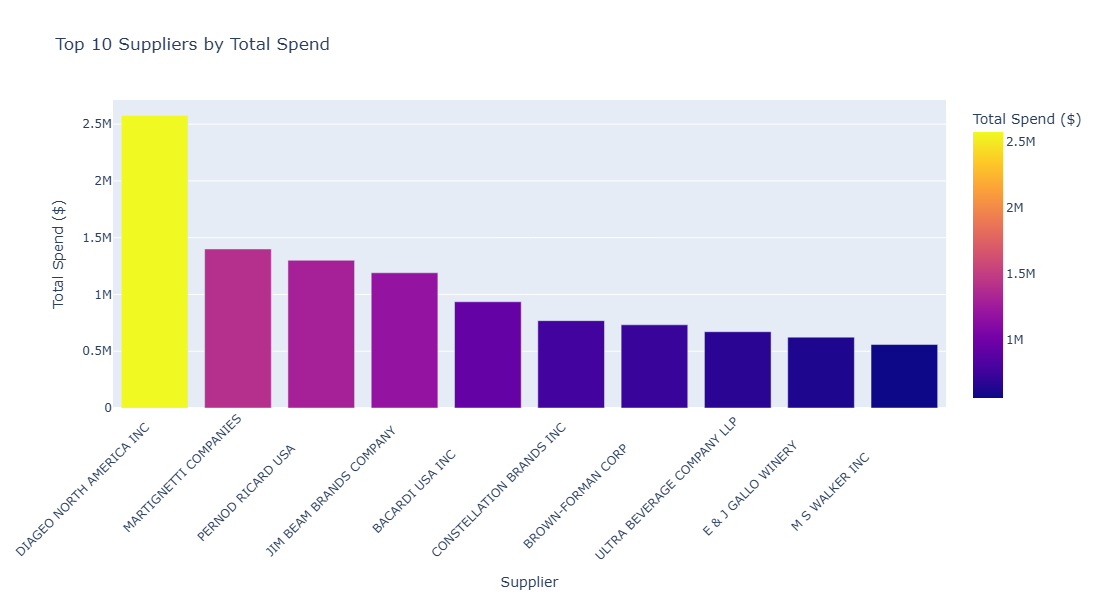

Top 10 Spend Bar Chart displayed successfully!


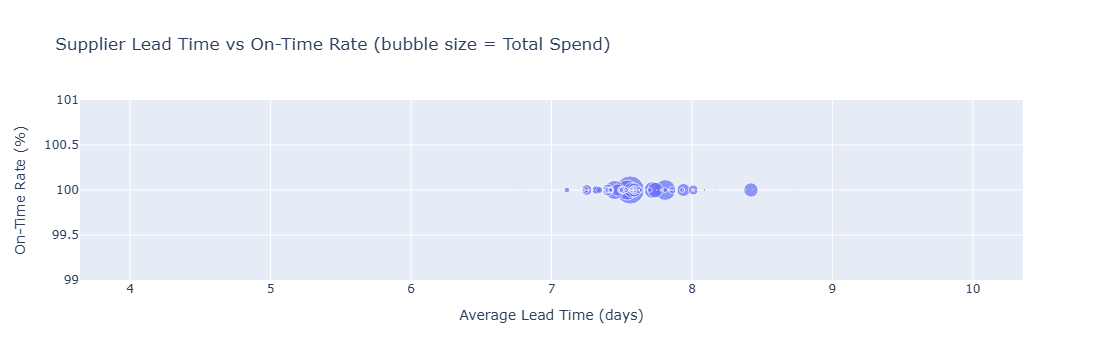

Lead Time vs On-Time Rate Scatter Chart displayed successfully!


In [5]:
import pandas as pd
import plotly.express as px
supplier_summary = pd.read_csv('supplier_summary.csv')
top10 = supplier_summary.head(10)
fig1 = px.bar(top10, 
              x='VendorName', 
              y='Total_Spend', 
              title='Top 10 Suppliers by Total Spend',
              labels={'Total_Spend': 'Total Spend ($)', 'VendorName': 'Supplier'},
              color='Total_Spend',
              height=600)
fig1.update_layout(xaxis_tickangle=-45)
fig1.show()
print("Top 10 Spend Bar Chart displayed successfully!")
fig2 = px.scatter(supplier_summary, 
                  x='Avg_LeadTime', 
                  y='OnTime_Rate', 
                  size='Total_Spend',
                  hover_name='VendorName',
                  title='Supplier Lead Time vs On-Time Rate (bubble size = Total Spend)',
                  labels={'Avg_LeadTime': 'Average Lead Time (days)', 'OnTime_Rate': 'On-Time Rate (%)'})
fig2.show()
print("Lead Time vs On-Time Rate Scatter Chart displayed successfully!")